# Iris CNOT-chain QNN — 2 layer(s)

The circuit follows the supplied image exactly. Every layer has eight independent `w` phases, three serial heralded CNOTs, six independent `inter` phases and four final local beam splitters. Local training uses the exact normalized logical operation conditioned on all heralds; QPU training uses the physical Perceval circuit and returned BSCount.


Iris CNOT-chain QNN | 2 CNOT-chain layers | Perceval 1.1.0 + Merlin
Logical modes: 8
Physical modes: 20
Herald photons: 12
CNOT gates: 6
Ideal herald success: 1.6519518666964456e-07
Input features: 4
Trainable quantum parameters: 28
Trainable prefixes: ['w1_', 'inter1_', 'w2_', 'inter2_']

[Local mode] Exact conditional dual-rail autograd training
Epoch 01/100 | train_loss=0.5569 | train_acc=0.886 | test_loss=0.4990 | test_acc=0.800 | time=0.328s
Epoch 02/100 | train_loss=0.3420 | train_acc=0.943 | test_loss=0.3679 | test_acc=0.900 | time=0.333s
Epoch 03/100 | train_loss=0.1874 | train_acc=0.986 | test_loss=0.2696 | test_acc=0.933 | time=0.325s
Epoch 04/100 | train_loss=0.0910 | train_acc=0.986 | test_loss=0.2463 | test_acc=0.933 | time=0.335s
Epoch 05/100 | train_loss=0.0481 | train_acc=1.000 | test_loss=0.1959 | test_acc=0.933 | time=0.317s
Epoch 06/100 | train_loss=0.0284 | train_acc=1.000 | test_loss=0.1620 | test_acc=0.933 | time=0.294s
Epoch 07/100 | train_loss=0.0247 | train_acc

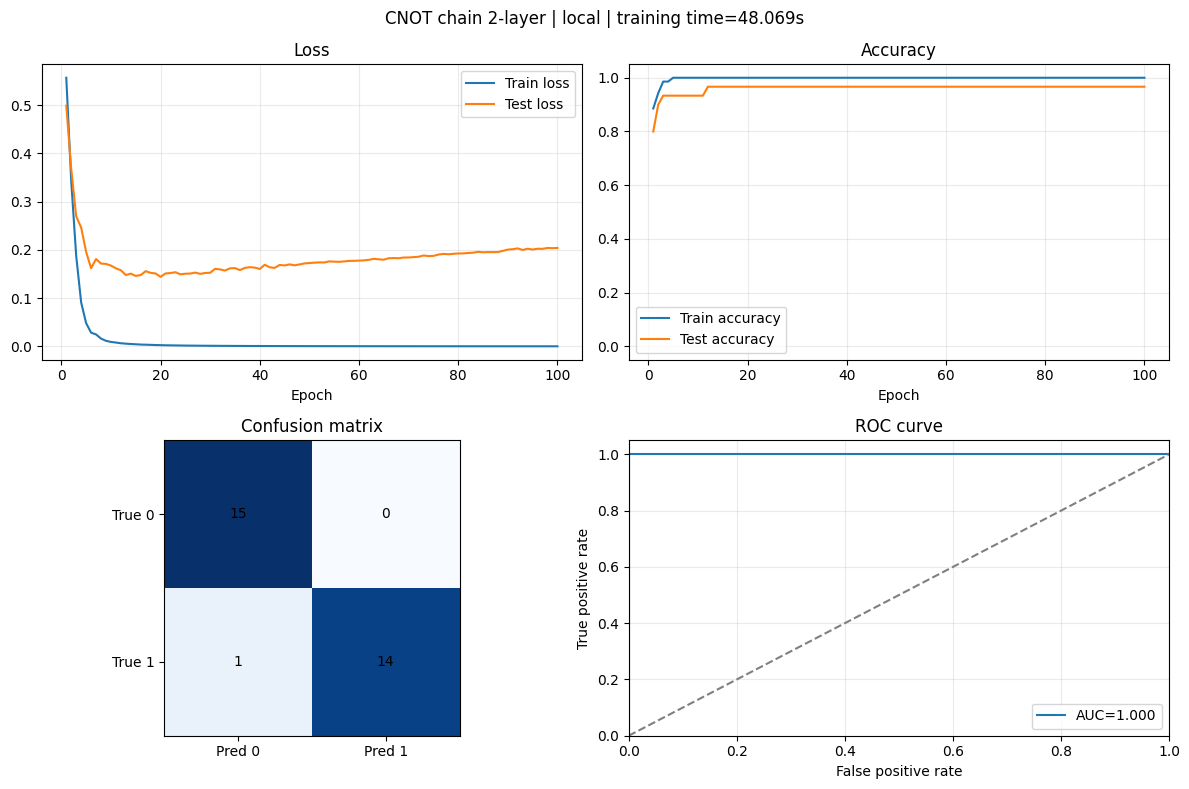

In [2]:
"""Iris full-chain CNOT-QNN with local autograd and Belenos BSCount training."""

import json
import math
import os
import time

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

import perceval as pcvl
from perceval.algorithm import Sampler
from perceval.components import BS, PS


from sklearn.datasets import load_iris as sklearn_load_iris
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset


# ============================================================
# Configuration
# ============================================================

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

N_QUBITS = 4
N_MODES = 2 * N_QUBITS
N_FEATURES = 4
CNOT_CATALOG_NAME = "heralded cnot"
DISPLAY_CIRCUIT = False
N_LAYERS = 2

IRIS_CLASS_0 = 0
IRIS_CLASS_1 = 1
TRAIN_SIZE = 70
TEST_SIZE = 30

LOCAL_EPOCHS = 100
LOCAL_BATCH_SIZE = 4
LOCAL_LR = 0.01

AUTO_PLOT = True
AUTO_SAVE_HISTORY = True
HISTORY_DIRECTORY = r"C:\Quantum"

# False: differentiable local Merlin training.
# True: hardware-in-the-loop SPSA training from qpu:belenos BSCount.
RUN_BELENOS = False
QPU_NAME = os.getenv("QUANDELA_PLATFORM", "qpu:belenos")
QPU_TOKEN = os.getenv("QUANDELA_CLOUD_TOKEN") or None
QPU_SHOTS = 300
QPU_SPSA_STEPS = 2
QPU_BATCH_SIZE = 2
QPU_TEST_SAMPLES = 5
QPU_CLASSICAL_LR = 0.02

SPSA_A0 = 0.12
SPSA_C0 = 0.18
SPSA_ALPHA = 0.602
SPSA_GAMMA = 0.101
SPSA_STABILITY = 3.0


# ============================================================
# Dataset
# ============================================================

def get_iris_binary_dataset():
    iris = sklearn_load_iris()
    x_all = iris.data.astype(np.float32)
    y_all = iris.target.astype(np.int64)

    mask = (y_all == IRIS_CLASS_0) | (y_all == IRIS_CLASS_1)
    x_all = x_all[mask]
    y_all = (y_all[mask] == IRIS_CLASS_1).astype(np.float32)

    x_train, x_test, y_train, y_test = train_test_split(
        x_all,
        y_all,
        train_size=TRAIN_SIZE,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=y_all,
    )

    scaler = MinMaxScaler(feature_range=(0.0, 2.0 * math.pi))
    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)

    return (
        torch.tensor(x_train, dtype=torch.float32),
        torch.tensor(x_test, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.float32),
    )


# ============================================================
# Physical Perceval circuit and exact conditional logical simulator
# ============================================================

def add_full_cnot_chain(processor):
    """Add q0->q1, q1->q2 and q2->q3 as shown in the reference image."""
    for control_qubit, target_qubit in ((0, 1), (1, 2), (2, 3)):
        mapping = (
            2 * control_qubit,
            2 * control_qubit + 1,
            2 * target_qubit,
            2 * target_qubit + 1,
        )
        processor.add(
            mapping,
            pcvl.catalog[CNOT_CATALOG_NAME].build_processor(),
        )


def build_photonic_qnn():
    """Build the exact heralded circuit from the image for N_LAYERS."""
    processor = pcvl.Processor("SLOS", N_MODES)
    x_params = [pcvl.P(f"x{i}") for i in range(N_FEATURES)]
    trainable_params = []
    trainable_prefixes = []

    # Identical Iris encoder to the MZI files: BS -> PS(x_i) -> BS.
    for qubit in range(N_QUBITS):
        processor.add(2 * qubit, BS.Ry())
        processor.add(2 * qubit + 1, PS(phi=x_params[qubit]))
        processor.add(2 * qubit, BS.Ry())

    for layer in range(1, N_LAYERS + 1):
        weight_prefix = f"w{layer}_"
        inter_prefix = f"inter{layer}_"
        trainable_prefixes.extend([weight_prefix, inter_prefix])

        weights = [pcvl.P(f"{weight_prefix}{mode}") for mode in range(N_MODES)]
        inter_params = [pcvl.P(f"{inter_prefix}{mode}") for mode in range(1, 7)]
        trainable_params.extend(weights)
        trainable_params.extend(inter_params)

        # Eight independent phase shifts followed by four local beam splitters.
        for qubit in range(N_QUBITS):
            processor.add(2 * qubit, PS(phi=weights[2 * qubit]))
            processor.add(2 * qubit + 1, PS(phi=weights[2 * qubit + 1]))
            processor.add(2 * qubit, BS.Ry())

        # Replace the three MZI cross-mode beam splitters with the full CNOT chain.
        add_full_cnot_chain(processor)

        # Six independent inter phases and four final local beam splitters.
        for mode in range(1, 7):
            processor.add(mode, PS(phi=inter_params[mode - 1]))
        for qubit in range(N_QUBITS):
            processor.add(2 * qubit, BS.Ry())

    processor.with_input(pcvl.BasicState([1, 0] * N_QUBITS))
    return (
        processor.linear_circuit(),
        processor,
        x_params,
        trainable_params,
        trainable_prefixes,
    )


def _basis_indices(qubit, bit):
    shift = N_QUBITS - 1 - qubit
    return [index for index in range(2**N_QUBITS) if ((index >> shift) & 1) == bit]


def _apply_ry(state, qubit, theta):
    """Apply Perceval BS.Ry(theta) exactly in the dual-rail logical basis."""
    indices_0 = torch.tensor(_basis_indices(qubit, 0), device=state.device)
    indices_1 = torch.tensor(_basis_indices(qubit, 1), device=state.device)
    amplitude_0 = state.index_select(1, indices_0)
    amplitude_1 = state.index_select(1, indices_1)

    theta = torch.as_tensor(theta, dtype=state.real.dtype, device=state.device)
    cosine = torch.cos(theta / 2.0)
    sine = torch.sin(theta / 2.0)
    if cosine.ndim == 1:
        cosine = cosine.unsqueeze(1)
        sine = sine.unsqueeze(1)

    output = state.clone()
    output[:, indices_0] = cosine * amplitude_0 - sine * amplitude_1
    output[:, indices_1] = sine * amplitude_0 + cosine * amplitude_1
    return output


def _apply_mode_phase(state, mode, phase):
    """Apply PS(phi) to one physical rail while remaining in dual rail."""
    qubit, rail = divmod(mode, 2)
    indices = torch.tensor(_basis_indices(qubit, rail), device=state.device)
    phase = torch.as_tensor(phase, dtype=state.real.dtype, device=state.device)
    factor = torch.exp(1j * phase)
    if factor.ndim == 1:
        factor = factor.unsqueeze(1)

    output = state.clone()
    output[:, indices] = output[:, indices] * factor
    return output


def _cnot_permutation(control, target):
    permutation = []
    for output_index in range(2**N_QUBITS):
        bits = [
            (output_index >> (N_QUBITS - 1 - qubit)) & 1
            for qubit in range(N_QUBITS)
        ]
        # CNOT is self-inverse, so this maps output index to its input index.
        bits[target] ^= bits[control]
        input_index = 0
        for bit in bits:
            input_index = (input_index << 1) | bit
        permutation.append(input_index)
    return torch.tensor(permutation, dtype=torch.long)


class LogicalCNOTQuantumLayer(nn.Module):
    """Differentiable logical simulation conditioned on every herald succeeding.

    A full physical Fock simulation becomes intractable beyond one layer because
    every CNOT adds two ancilla photons/modes. Since all local gates and an ideal
    heralded CNOT preserve dual rail on the successful branch, this 16-amplitude
    simulator is exactly the normalized conditional logical operation.
    """

    def __init__(self):
        super().__init__()
        for layer in range(1, N_LAYERS + 1):
            self.register_parameter(
                f"w{layer}_",
                nn.Parameter(torch.randn(N_MODES, dtype=torch.float32) * math.pi),
            )
            self.register_parameter(
                f"inter{layer}_",
                nn.Parameter(torch.randn(6, dtype=torch.float32) * math.pi),
            )

        self.register_buffer("cnot_01", _cnot_permutation(0, 1))
        self.register_buffer("cnot_12", _cnot_permutation(1, 2))
        self.register_buffer("cnot_23", _cnot_permutation(2, 3))

    def statevector(self, x):
        batch_size = x.shape[0]
        state = torch.zeros(
            batch_size,
            2**N_QUBITS,
            dtype=torch.complex64,
            device=x.device,
        )
        state[:, 0] = 1.0

        # BS -> PS(x_i) -> BS feature encoder.
        for qubit in range(N_QUBITS):
            state = _apply_ry(state, qubit, math.pi / 2.0)
            state = _apply_mode_phase(state, 2 * qubit + 1, x[:, qubit])
            state = _apply_ry(state, qubit, math.pi / 2.0)

        for layer in range(1, N_LAYERS + 1):
            weights = getattr(self, f"w{layer}_")
            inter = getattr(self, f"inter{layer}_")

            for mode in range(N_MODES):
                state = _apply_mode_phase(state, mode, weights[mode])
            for qubit in range(N_QUBITS):
                state = _apply_ry(state, qubit, math.pi / 2.0)

            state = state.index_select(1, self.cnot_01)
            state = state.index_select(1, self.cnot_12)
            state = state.index_select(1, self.cnot_23)

            for mode in range(1, 7):
                state = _apply_mode_phase(state, mode, inter[mode - 1])
            for qubit in range(N_QUBITS):
                state = _apply_ry(state, qubit, math.pi / 2.0)

        return state

    def forward(self, x):
        state = self.statevector(x)
        probabilities = state.abs().square()
        expectations = []
        for qubit in range(N_QUBITS):
            for rail in (0, 1):
                indices = torch.tensor(
                    _basis_indices(qubit, rail),
                    device=state.device,
                )
                expectations.append(probabilities.index_select(1, indices).sum(dim=1))
        return torch.stack(expectations, dim=1)


class IrisPhotonicQNN(nn.Module):
    def __init__(self, circuit=None, trainable_prefixes=None):
        super().__init__()
        self.q_layer = LogicalCNOTQuantumLayer()
        self.fc = nn.Sequential(
            nn.LayerNorm(N_MODES),
            nn.Linear(N_MODES, 1),
        )

    def forward(self, x):
        expectations = self.q_layer(x)
        return self.fc(expectations).squeeze(-1)


# ============================================================
# Metrics and local differentiable training
# ============================================================

def metrics_from_logits(logits, targets, criterion):
    loss = criterion(logits, targets)
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities >= 0.5).float()
    accuracy = (predictions == targets).float().mean()
    return loss, accuracy, probabilities, predictions


def classification_metrics_from_probabilities(targets, probabilities):
    y_true = targets.detach().cpu().numpy().astype(np.int64)
    y_probability = probabilities.detach().cpu().numpy()
    y_prediction = (y_probability >= 0.5).astype(np.int64)

    matrix = confusion_matrix(y_true, y_prediction, labels=[0, 1])
    precision = precision_score(y_true, y_prediction, zero_division=0)
    recall = recall_score(y_true, y_prediction, zero_division=0)
    roc_auc = (
        roc_auc_score(y_true, y_probability)
        if np.unique(y_true).size == 2
        else float("nan")
    )

    return {
        "confusion_matrix": matrix,
        "precision": float(precision),
        "recall": float(recall),
        "roc_auc": float(roc_auc),
    }


def print_classification_metrics(label, targets, probabilities):
    metrics = classification_metrics_from_probabilities(targets, probabilities)
    matrix = metrics["confusion_matrix"]
    print(f"{label} confusion matrix [[TN, FP], [FN, TP]]: {matrix.tolist()}")
    print(f"{label} precision: {metrics['precision']:.4f}")
    print(f"{label} recall/sensitivity: {metrics['recall']:.4f}")
    print(f"{label} ROC-AUC: {metrics['roc_auc']:.4f}")
    return metrics


def evaluate_local(model, x, y, criterion):
    model.eval()
    with torch.no_grad():
        return metrics_from_logits(model(x), y, criterion)


def train_local(model, x_train, x_test, y_train, y_test):
    loader = DataLoader(
        TensorDataset(x_train, y_train),
        batch_size=LOCAL_BATCH_SIZE,
        shuffle=True,
    )
    optimizer = optim.Adam(model.parameters(), lr=LOCAL_LR)
    criterion = nn.BCEWithLogitsLoss()
    total_start = time.time()

    history = {
        "mode": "local",
        "layers": N_LAYERS,
        "dataset": {
            "train_samples": int(len(x_train)),
            "test_samples": int(len(x_test)),
            "evaluated_test_samples": int(len(x_test)),
        },
        "epoch": [],
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": [],
        "epoch_time_s": [],
    }
    quantum_before = {
        name: parameter.detach().clone()
        for name, parameter in model.q_layer.named_parameters()
    }

    training_start = time.time()
    for epoch in range(1, LOCAL_EPOCHS + 1):
        epoch_start = time.time()
        model.train()
        total_loss = 0.0

        for xb, yb in loader:
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(xb)

        train_loss = total_loss / len(x_train)
        _, train_acc, _, _ = evaluate_local(model, x_train, y_train, criterion)
        test_loss, test_acc, _, _ = evaluate_local(model, x_test, y_test, criterion)
        epoch_time = time.time() - epoch_start

        history["epoch"].append(epoch)
        history["train_loss"].append(float(train_loss))
        history["train_accuracy"].append(float(train_acc.item()))
        history["test_loss"].append(float(test_loss.item()))
        history["test_accuracy"].append(float(test_acc.item()))
        history["epoch_time_s"].append(float(epoch_time))

        print(
            f"Epoch {epoch:02d}/{LOCAL_EPOCHS} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc.item():.3f} | "
            f"test_loss={test_loss.item():.4f} | test_acc={test_acc.item():.3f} | "
            f"time={epoch_time:.3f}s"
        )

    training_time = time.time() - training_start
    evaluation_start = time.time()
    test_loss, test_acc, probabilities, predictions = evaluate_local(
        model, x_test, y_test, criterion
    )
    evaluation_time = time.time() - evaluation_start
    total_wall_time = time.time() - total_start

    max_delta = max(
        (parameter.detach() - quantum_before[name]).abs().max().item()
        for name, parameter in model.q_layer.named_parameters()
    )
    classification = print_classification_metrics("Local test", y_test, probabilities)

    history["timing"] = {
        "training_time_s": float(training_time),
        "evaluation_time_s": float(evaluation_time),
        "total_wall_time_s": float(total_wall_time),
    }
    history["final_test"] = {
        "loss": float(test_loss.item()),
        "accuracy": float(test_acc.item()),
        "precision": classification["precision"],
        "recall_sensitivity": classification["recall"],
        "roc_auc": classification["roc_auc"],
        "confusion_matrix": classification["confusion_matrix"].tolist(),
        "probabilities": probabilities.tolist(),
        "predictions": predictions.tolist(),
        "labels": y_test.tolist(),
    }
    history["quantum_parameter_max_delta"] = float(max_delta)

    print(f"Local training time: {training_time:.3f}s")
    print(f"Local final evaluation time: {evaluation_time:.3f}s")
    print(f"Local total wall time: {total_wall_time:.3f}s")
    print("Quantum parameters updated:", max_delta > 0)
    print("Max |delta quantum parameters|:", max_delta)
    print(f"Final local loss={test_loss.item():.4f} | accuracy={test_acc.item():.3f}")
    print("Probabilities:", probabilities.tolist())
    print("Predictions  :", predictions.tolist())
    print("Labels       :", y_test.tolist())
    return history


# ============================================================
# Merlin parameter storage <-> Perceval parameter names
# ============================================================

def parameter_layout():
    layout = []
    for layer in range(1, N_LAYERS + 1):
        layout.append((f"w{layer}_", N_MODES, 0))
        layout.append((f"inter{layer}_", 6, 1))
    return layout


def flatten_quantum_parameters(model):
    chunks = []
    for prefix, _, _ in parameter_layout():
        chunks.append(getattr(model.q_layer, prefix).detach().flatten())
    return torch.cat(chunks).clone()


def assign_quantum_parameters(model, theta):
    offset = 0
    with torch.no_grad():
        for prefix, size, _ in parameter_layout():
            parameter = getattr(model.q_layer, prefix)
            parameter.copy_(theta[offset : offset + size].view_as(parameter))
            offset += size


def wrap_phases(theta):
    return torch.remainder(theta + math.pi, 2.0 * math.pi) - math.pi


def theta_to_perceval_parameters(theta):
    values = {}
    offset = 0

    for prefix, size, first_index in parameter_layout():
        for local_index in range(size):
            values[f"{prefix}{local_index + first_index}"] = float(
                theta[offset + local_index]
            )
        offset += size

    return values


def input_to_perceval_parameters(x):
    return {f"x{index}": float(x[index]) for index in range(N_FEATURES)}


# ============================================================
# Belenos BSCount execution and expectation values
# ============================================================

def bscount_to_mode_expectations(counts):
    """Convert BSCount to Merlin UNBUNCHED mode expectation values."""
    total_count = float(sum(counts.values()))
    if total_count <= 0:
        raise RuntimeError("The QPU returned an empty BSCount result.")

    expectations = torch.zeros(N_MODES, dtype=torch.float32)
    for state, count in counts.items():
        for mode in range(N_MODES):
            # UNBUNCHED expectation = P(mode contains at least one photon).
            expectations[mode] += float(count) * float(state[mode] >= 1)

    return expectations / total_count


class BelenosBSCountRunner:
    def __init__(self, processor_template, token, shots=QPU_SHOTS):
        if not token:
            raise RuntimeError(
                "Missing QUANDELA_CLOUD_TOKEN. Set it before enabling RUN_BELENOS."
            )
        if QPU_NAME != "qpu:belenos":
            raise ValueError(
                f"Expected QPU_NAME='qpu:belenos', received {QPU_NAME!r}."
            )

        self.shots = int(shots)
        self.processor = pcvl.RemoteProcessor(QPU_NAME, token=token)
        self.processor.set_circuit(processor_template.linear_circuit())
        for mode, photon_count in processor_template.heralds.items():
            self.processor.add_herald(mode, photon_count)
        self.processor.with_input(pcvl.BasicState([1, 0] * N_QUBITS))
        self.sampler = Sampler(self.processor)
        self.last_diagnostics = []

        print("Connected platform:", self.processor.name)
        print("Platform status:", self.processor.status)
        print("Available commands:", self.processor.available_commands)
        print("Logical modes:", self.processor.m)
        print("Physical modes:", self.processor.circuit_size)
        print("Heralds:", self.processor.heralds)

    def sample_counts(self, x, theta):
        values = theta_to_perceval_parameters(theta)
        values.update(input_to_perceval_parameters(x))

        circuit_parameters = self.processor.get_circuit_parameters()
        missing = set(values).difference(circuit_parameters)
        if missing:
            raise RuntimeError(f"Circuit parameters not found on QPU: {sorted(missing)}")
        for name, value in values.items():
            circuit_parameters[name].set_value(value)

        result = self.sampler.sample_count.execute_sync(max_samples=self.shots)
        counts = result.get("results")
        if counts is None:
            raise RuntimeError(f"Unexpected QPU result keys: {list(result)}")
        return counts, result

    def expectation_batch(self, x_batch, theta, verbose=False):
        rows = []
        diagnostics = []
        for sample_index, x in enumerate(x_batch):
            counts, result = self.sample_counts(x, theta)
            expectations = bscount_to_mode_expectations(counts)
            accepted = float(sum(counts.values()))
            global_perf = result.get("global_perf")
            global_perf = float(global_perf) if global_perf is not None else float("nan")
            rows.append(expectations)
            diagnostics.append({"accepted_count": accepted, "global_perf": global_perf})
            if verbose:
                print(
                    f"  sample={sample_index} | accepted={accepted:.0f} | "
                    f"global_perf={global_perf:.6g} | "
                    f"expectations={[round(v, 4) for v in expectations.tolist()]}"
                )
        self.last_diagnostics = diagnostics
        return torch.stack(rows)


def balanced_batch_indices(labels, batch_size):
    positive = torch.where(labels >= 0.5)[0]
    negative = torch.where(labels < 0.5)[0]
    half = max(1, batch_size // 2)

    positive_ids = positive[torch.randperm(len(positive))[:half]]
    negative_ids = negative[torch.randperm(len(negative))[:half]]
    indices = torch.cat([positive_ids, negative_ids])

    if len(indices) < batch_size:
        remaining = torch.randperm(len(labels))[: batch_size - len(indices)]
        indices = torch.cat([indices, remaining])

    return indices[:batch_size]


def qpu_loss_and_accuracy(model, expectations, targets, criterion):
    logits = model.fc(expectations).squeeze(-1)
    loss, accuracy, probabilities, predictions = metrics_from_logits(
        logits, targets, criterion
    )
    return loss, accuracy, probabilities, predictions, logits


# ============================================================
# Hardware-in-the-loop SPSA training from BSCount
# ============================================================

def train_on_belenos(model, processor, x_train, x_test, y_train, y_test):
    total_start = time.time()
    criterion = nn.BCEWithLogitsLoss()
    classical_optimizer = optim.Adam(model.fc.parameters(), lr=QPU_CLASSICAL_LR)
    runner = BelenosBSCountRunner(processor, QPU_TOKEN, shots=QPU_SHOTS)

    theta = wrap_phases(flatten_quantum_parameters(model))
    assign_quantum_parameters(model, theta)
    theta_before = theta.clone()
    expected_jobs = 3 * QPU_BATCH_SIZE * QPU_SPSA_STEPS + min(
        QPU_TEST_SAMPLES, len(x_test)
    )
    history = {
        "mode": "qpu_bscount",
        "layers": N_LAYERS,
        "dataset": {
            "train_samples": int(len(x_train)),
            "test_samples": int(len(x_test)),
            "evaluated_test_samples": int(min(QPU_TEST_SAMPLES, len(x_test))),
        },
        "qpu_name": QPU_NAME,
        "shots_per_job": QPU_SHOTS,
        "expected_jobs": int(expected_jobs),
        "step": [],
        "loss_plus": [],
        "loss_minus": [],
        "train_loss": [],
        "train_accuracy": [],
        "quantum_gradient_norm": [],
        "step_time_s": [],
    }

    print(f"Quantum parameters: {theta.numel()}")
    print(f"Expected QPU jobs for this run: approximately {expected_jobs}")
    print("Every reported QPU metric below is computed from BSCount.")

    training_start = time.time()
    for step in range(1, QPU_SPSA_STEPS + 1):
        step_start = time.time()
        ids = balanced_batch_indices(y_train, QPU_BATCH_SIZE)
        xb = x_train[ids]
        yb = y_train[ids]

        ak = SPSA_A0 / ((step + SPSA_STABILITY) ** SPSA_ALPHA)
        ck = SPSA_C0 / (step**SPSA_GAMMA)
        delta = 2.0 * torch.randint(0, 2, theta.shape).float() - 1.0

        theta_plus = wrap_phases(theta + ck * delta)
        theta_minus = wrap_phases(theta - ck * delta)
        plus_expectations = runner.expectation_batch(xb, theta_plus)
        minus_expectations = runner.expectation_batch(xb, theta_minus)

        with torch.no_grad():
            loss_plus = qpu_loss_and_accuracy(
                model, plus_expectations, yb, criterion
            )[0].item()
            loss_minus = qpu_loss_and_accuracy(
                model, minus_expectations, yb, criterion
            )[0].item()

        quantum_gradient = ((loss_plus - loss_minus) / (2.0 * ck)) * delta
        theta = wrap_phases(theta - ak * quantum_gradient)
        assign_quantum_parameters(model, theta)

        updated_expectations = runner.expectation_batch(xb, theta, verbose=True)
        classical_optimizer.zero_grad(set_to_none=True)
        train_loss, _, _, _, _ = qpu_loss_and_accuracy(
            model, updated_expectations, yb, criterion
        )
        train_loss.backward()
        classical_optimizer.step()

        with torch.no_grad():
            train_loss, train_acc, probabilities, predictions, _ = qpu_loss_and_accuracy(
                model, updated_expectations, yb, criterion
            )

        step_time = time.time() - step_start
        history["step"].append(step)
        history["loss_plus"].append(float(loss_plus))
        history["loss_minus"].append(float(loss_minus))
        history["train_loss"].append(float(train_loss.item()))
        history["train_accuracy"].append(float(train_acc.item()))
        history["quantum_gradient_norm"].append(float(quantum_gradient.norm().item()))
        history["step_time_s"].append(float(step_time))

        print(
            f"SPSA {step:02d}/{QPU_SPSA_STEPS} | "
            f"loss_plus={loss_plus:.4f} | loss_minus={loss_minus:.4f} | "
            f"BSCount_loss={train_loss.item():.4f} | "
            f"BSCount_acc={train_acc.item():.3f} | "
            f"q_grad_norm={quantum_gradient.norm().item():.6f} | "
            f"time={step_time:.2f}s"
        )

    training_time = time.time() - training_start
    evaluation_start = time.time()
    test_count = min(QPU_TEST_SAMPLES, len(x_test))
    test_expectations = runner.expectation_batch(
        x_test[:test_count], theta, verbose=True
    )
    with torch.no_grad():
        test_loss, test_acc, probabilities, predictions, _ = qpu_loss_and_accuracy(
            model, test_expectations, y_test[:test_count], criterion
        )
    evaluation_time = time.time() - evaluation_start
    total_wall_time = time.time() - total_start

    max_delta = (theta - theta_before).abs().max().item()
    classification = print_classification_metrics(
        "QPU BSCount test", y_test[:test_count], probabilities
    )
    history["timing"] = {
        "training_time_s": float(training_time),
        "evaluation_time_s": float(evaluation_time),
        "total_wall_time_s": float(total_wall_time),
    }
    history["final_test"] = {
        "loss": float(test_loss.item()),
        "accuracy": float(test_acc.item()),
        "precision": classification["precision"],
        "recall_sensitivity": classification["recall"],
        "roc_auc": classification["roc_auc"],
        "confusion_matrix": classification["confusion_matrix"].tolist(),
        "probabilities": probabilities.tolist(),
        "predictions": predictions.tolist(),
        "labels": y_test[:test_count].tolist(),
        "mode_expectations": test_expectations.tolist(),
    }
    history["quantum_parameter_max_delta"] = float(max_delta)

    print(f"QPU SPSA training time: {training_time:.3f}s")
    print(f"QPU final evaluation time: {evaluation_time:.3f}s")
    print(f"QPU total wall time: {total_wall_time:.3f}s")
    print("Quantum parameters updated from BSCount:", max_delta > 0)
    print("Max |delta quantum parameters|:", max_delta)
    print(f"Final QPU loss={test_loss.item():.4f} | accuracy={test_acc.item():.3f}")
    print("QPU probabilities:", probabilities.tolist())
    print("QPU predictions  :", predictions.tolist())
    print("QPU labels       :", y_test[:test_count].tolist())
    return history


# ============================================================
# History export and plots
# ============================================================

def save_history_json(history, path=None):
    if path is None:
        path = os.path.join(
            HISTORY_DIRECTORY,
            f"CNOT-chain-{N_LAYERS}layers-{history['mode']}-history.json",
        )
    with open(path, "w", encoding="utf-8") as file:
        json.dump(history, file, indent=2, ensure_ascii=False)
    print("History saved to:", path)
    return path


def plot_training_history(history):
    import matplotlib.pyplot as plt

    figure, axes = plt.subplots(2, 2, figsize=(12, 8))
    mode = history["mode"]

    if mode == "local":
        x_axis = history["epoch"]
        axes[0, 0].plot(x_axis, history["train_loss"], label="Train loss")
        axes[0, 0].plot(x_axis, history["test_loss"], label="Test loss")
        axes[0, 1].plot(x_axis, history["train_accuracy"], label="Train accuracy")
        axes[0, 1].plot(x_axis, history["test_accuracy"], label="Test accuracy")
        x_label = "Epoch"
    else:
        x_axis = history["step"]
        axes[0, 0].plot(x_axis, history["train_loss"], marker="o", label="BSCount loss")
        axes[0, 0].plot(x_axis, history["loss_plus"], linestyle="--", label="Loss +")
        axes[0, 0].plot(x_axis, history["loss_minus"], linestyle="--", label="Loss -")
        axes[0, 1].plot(
            x_axis, history["train_accuracy"], marker="o", label="BSCount accuracy"
        )
        x_label = "SPSA step"

    axes[0, 0].set_title("Loss")
    axes[0, 0].set_xlabel(x_label)
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.25)

    axes[0, 1].set_title("Accuracy")
    axes[0, 1].set_xlabel(x_label)
    axes[0, 1].set_ylim(-0.05, 1.05)
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.25)

    final_test = history["final_test"]
    matrix = np.asarray(final_test["confusion_matrix"])
    axes[1, 0].imshow(matrix, cmap="Blues")
    axes[1, 0].set_title("Confusion matrix")
    axes[1, 0].set_xticks([0, 1])
    axes[1, 0].set_yticks([0, 1])
    axes[1, 0].set_xticklabels(["Pred 0", "Pred 1"])
    axes[1, 0].set_yticklabels(["True 0", "True 1"])
    for row in range(2):
        for column in range(2):
            axes[1, 0].text(column, row, int(matrix[row, column]), ha="center", va="center")

    labels = np.asarray(final_test["labels"], dtype=np.int64)
    probabilities = np.asarray(final_test["probabilities"], dtype=float)
    if np.unique(labels).size == 2:
        false_positive_rate, true_positive_rate, _ = roc_curve(labels, probabilities)
        axes[1, 1].plot(
            false_positive_rate,
            true_positive_rate,
            label=f"AUC={final_test['roc_auc']:.3f}",
        )
    axes[1, 1].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[1, 1].set_xlim(0, 1)
    axes[1, 1].set_ylim(0, 1.05)
    axes[1, 1].set_xlabel("False positive rate")
    axes[1, 1].set_ylabel("True positive rate")
    axes[1, 1].set_title("ROC curve")
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.25)

    training_time = history["timing"]["training_time_s"]
    figure.suptitle(
        f"CNOT chain {N_LAYERS}-layer | {mode} | training time={training_time:.3f}s"
    )
    figure.tight_layout()
    plt.show()
    return figure, axes


# ============================================================
# Main
# ============================================================

def main():
    print("=" * 68)
    print(f"Iris CNOT-chain QNN | {N_LAYERS} CNOT-chain layers | Perceval 1.1.0 + Merlin")
    print("=" * 68)

    x_train, x_test, y_train, y_test = get_iris_binary_dataset()
    circuit, processor, x_params, trainable_params, trainable_prefixes = build_photonic_qnn()

    print("Logical modes:", processor.m)
    print("Physical modes:", processor.circuit_size)
    print("Herald photons:", sum(processor.heralds.values()))
    print("CNOT gates:", 3 * N_LAYERS)
    print("Ideal herald success:", (2.0 / 27.0) ** (3 * N_LAYERS))
    print("Input features:", len(x_params))
    print("Trainable quantum parameters:", len(trainable_params))
    print("Trainable prefixes:", trainable_prefixes)
    if DISPLAY_CIRCUIT:
        pcvl.pdisplay(processor, recursive=True)

    model = IrisPhotonicQNN(circuit, trainable_prefixes)

    if RUN_BELENOS:
        print("\n[QPU mode] Training from qpu:belenos BSCount with SPSA")
        history = train_on_belenos(
            model, processor, x_train, x_test, y_train, y_test
        )
    else:
        print("\n[Local mode] Exact conditional dual-rail autograd training")
        history = train_local(model, x_train, x_test, y_train, y_test)

    return model, history


if __name__ == "__main__":
    MODEL, HISTORY = main()
    if AUTO_SAVE_HISTORY:
        HISTORY_PATH = save_history_json(HISTORY)
    if AUTO_PLOT:
        FIGURE, AXES = plot_training_history(HISTORY)
